In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import fisher_exact
import itertools

plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True

In [2]:
# Benjamini-Hochberg FDR correction
def fdr_bh(pvals):
    pvals = np.array(pvals)
    n = len(pvals)

    # Sort p-values
    order = np.argsort(pvals)
    ranked_pvals = pvals[order]

    # Compute BH values
    bh = ranked_pvals * n / (np.arange(1, n+1))
    bh = np.minimum.accumulate(bh[::-1])[::-1]

    # Cap at 1
    bh = np.minimum(bh, 1.0)

    # Return to original order
    adjusted = np.empty(n)
    adjusted[order] = bh

    return adjusted

In [3]:
def plot_tf_enrichment(df,
                       alpha=0.01,
                       pval=0.01,
                       only_enriched=False,
                       sort=True,
                       title="Significant TF Enrichment in Loop Anchors",
                       sd=None):

    df = df.copy()

    # do fisher's exact test for OR p-value
    odds_ratios = []
    pvals = []

    for _, row in df.iterrows():
        table = [[row["tf_overlap"], row["tf_not_overlap"]],
                 [row["control_overlap"], row["control_not_overlap"]]]
        
        or_val, p_val = fisher_exact(table, alternative="two-sided")
        
        odds_ratios.append(or_val)
        pvals.append(p_val)

    df["odds_ratio"] = odds_ratios
    df["log2_or"] = np.log2(df["odds_ratio"])
    df["pval"] = pvals

    df["fdr"] = fdr_bh(df["pval"])

    sig_df = df[(df["fdr"] < alpha)&(df["pval"] < pval)].copy()
    
    if only_enriched:
        sig_df = sig_df[sig_df["log2_or"] > 0]

    if sig_df.empty:
        print("No significant TFs found.")
        return df

    if sort:
        sig_df = sig_df.sort_values("log2_or")

    colors = ["#CC3311" if x > 0 else "#0077BB"
              for x in sig_df["log2_or"]]

    plt.figure()
    plt.barh(sig_df.index, sig_df["log2_or"], color=colors)
    plt.axvline(0)
    plt.xlabel("log2(Odds Ratio)")
    plt.title(title + f"\n(FDR < {alpha})")
    plt.tight_layout()
    
    if sd is not None:
        plt.savefig(sd)
    else:
        plt.show()

    return df

In [8]:
basedir = '/mnt/md0/varshini/Analysis/Blood/MicroC_Loops_Anchors_Merged_v2/'
savedir = '/mnt/md0/varshini/Analysis/Blood/figs_v4/fig1'

if not os.path.exists(savedir):
    os.mkdir(savedir)

/mnt/md0/varshini/Analysis/Blood/MicroC_Loops_Anchors_Merged_v2/erythroid_acrs_by_tf_against_atac_overlap_results_032524_combined_DAP_JAN_028_ATAC.txt
        tf_overlap  control_overlap  tf_not_overlap  control_not_overlap  \
TF                                                                         
BCL11A           8            78365              10               151616   
GATA1         3397            74976            1700               155005   
KLF1           178            78195             128               151786   
TAL1          2154            76219            1001               153762   
GFI1B         4804            73569            2415               156412   
NFE2          2365            76008            1499               153973   
LMO2           660            77713             216               152268   
ATF4             2            78371               1               151610   
SPI1          1215            77158             248               152823   
RUNX1        

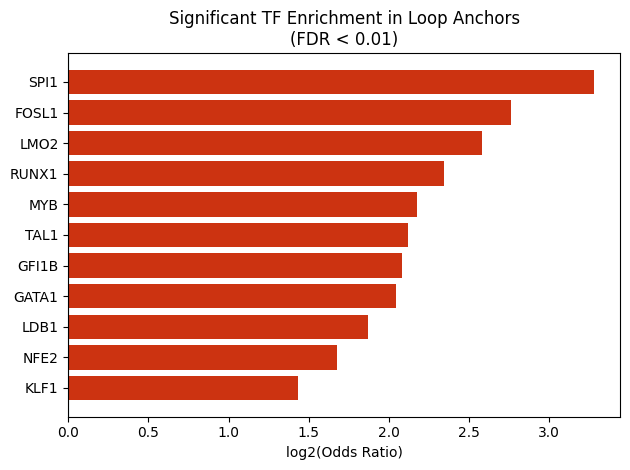

In [9]:

controls= ["032524_combined_DAP_JAN_028_ATAC"]
tests = ["erythroid_acrs_by_tf_against_atac"]
for test, control in list(itertools.product(tests, controls)):
    fname = os.path.join(basedir, f"{test}_overlap_results_{control}.txt")
    print(fname)
    df = pd.read_csv(fname, sep="\t", header=None,
                 names=["TF", "tf_overlap", "control_overlap",
                        "tf_not_overlap", "control_not_overlap"])

    df = df.set_index("TF")

    sd=os.path.join(savedir, f"{test}_overlap_results_{control}.svg")
    out = plot_tf_enrichment(df, sd=sd)
    print(out)

/mnt/md0/varshini/Analysis/Blood/MicroC_Loops_Anchors_Merged_v2/erythroid_acrs_by_tf_against_atac_overlap_results_P1_ATAC.txt


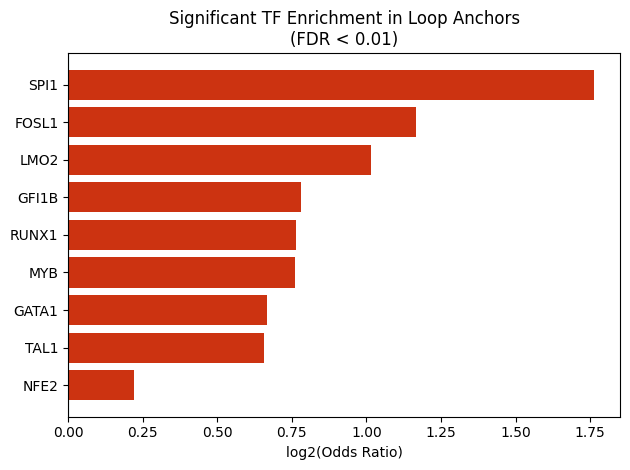

        tf_overlap  control_overlap  tf_not_overlap  control_not_overlap  \
TF                                                                         
BCL11A           8            37425              10                23615   
GATA1         3397            34026            1700                27014   
KLF1           178            37251             128                23789   
TAL1          2154            35241            1001                25799   
GFI1B         4804            32769            2415                28271   
NFE2          2365            35126            1499                25914   
LMO2           660            36737             216                24303   
ATF4             2            37430               1                23610   
SPI1          1215            36069             248                24971   
RUNX1          427            36955             164                24085   
FOSL1          237            37144              68                23896   
MYB         

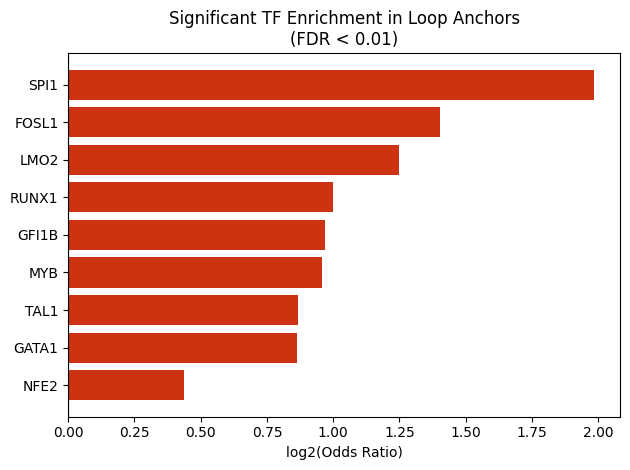

        tf_overlap  control_overlap  tf_not_overlap  control_not_overlap  \
TF                                                                         
BCL11A           8            45582              10                34086   
GATA1         3397            41689            1700                37979   
KLF1           178            45395             128                34273   
TAL1          2154            43094            1001                36574   
GFI1B         4804            40155            2415                39513   
NFE2          2365            42894            1499                36774   
LMO2           660            44806             216                34862   
ATF4             2            45588               1                34080   
SPI1          1215            44086             248                35582   
RUNX1          427            45054             164                34614   
FOSL1          237            45295              68                34373   
MYB         

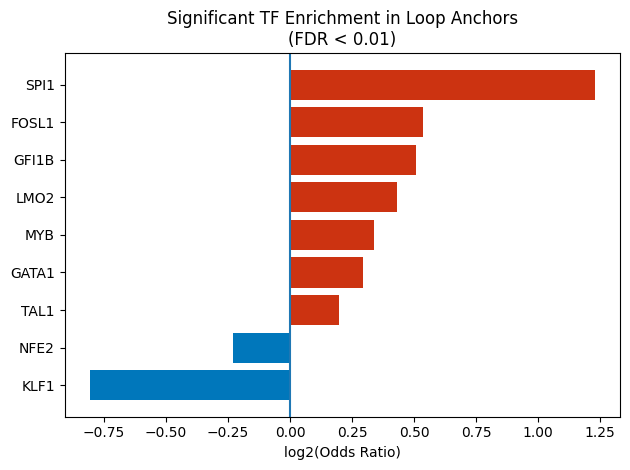

        tf_overlap  control_overlap  tf_not_overlap  control_not_overlap  \
TF                                                                         
BCL11A           8            28409              10                11436   
GATA1         3397            24685            1700                15160   
KLF1           178            28241             128                11604   
TAL1          2154            26002            1001                13843   
GFI1B         4804            23238            2415                16607   
NFE2          2365            25876            1499                13969   
LMO2           660            27657             216                12188   
ATF4             2            28415               1                11430   
SPI1          1215            26953             248                12892   
RUNX1          427            27899             164                11946   
FOSL1          237            28133              68                11712   
MYB         

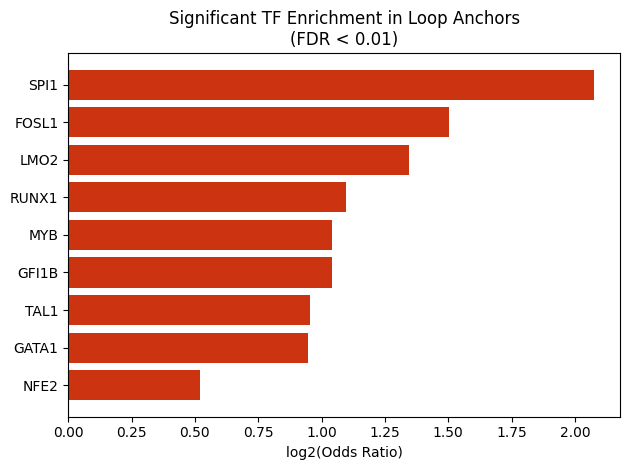

        tf_overlap  control_overlap  tf_not_overlap  control_not_overlap  \
TF                                                                         
BCL11A           8            47865              10                38395   
GATA1         3397            43938            1700                42322   
KLF1           178            47680             128                38580   
TAL1          2154            45369            1001                40891   
GFI1B         4804            42384            2415                43876   
NFE2          2365            45164            1499                41096   
LMO2           660            47092             216                39168   
ATF4             2            47870               1                38390   
SPI1          1215            46386             248                39874   
RUNX1          427            47347             164                38913   
FOSL1          237            47588              68                38672   
MYB         

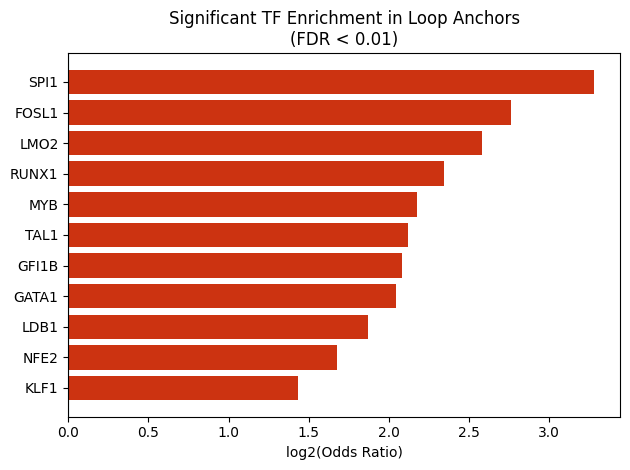

        tf_overlap  control_overlap  tf_not_overlap  control_not_overlap  \
TF                                                                         
BCL11A           8            78365              10               151616   
GATA1         3397            74976            1700               155005   
KLF1           178            78195             128               151786   
TAL1          2154            76219            1001               153762   
GFI1B         4804            73569            2415               156412   
NFE2          2365            76008            1499               153973   
LMO2           660            77713             216               152268   
ATF4             2            78371               1               151610   
SPI1          1215            77158             248               152823   
RUNX1          427            77946             164               152035   
FOSL1          237            78136              68               151845   
MYB         

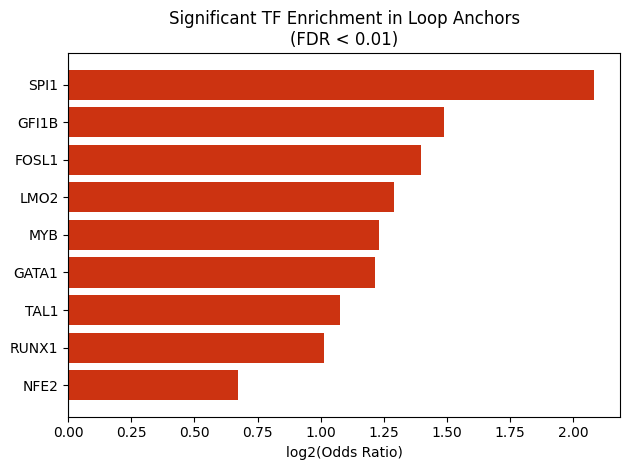

        tf_overlap  control_overlap  tf_not_overlap  control_not_overlap  \
TF                                                                         
BCL11A           8            17063              10                12485   
GATA1         3397            13674            1700                15874   
KLF1           178            16893             128                12655   
TAL1          2154            14917            1001                14631   
GFI1B         4804            12267            2415                17281   
NFE2          2365            14706            1499                14842   
LMO2           660            16411             216                13137   
ATF4             2            17069               1                12479   
SPI1          1215            15856             248                13692   
RUNX1          427            16644             164                12904   
FOSL1          237            16834              68                12714   
MYB         

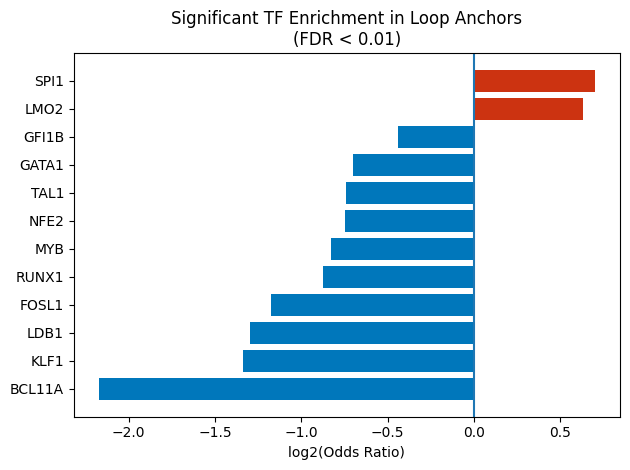

        tf_overlap  control_overlap  tf_not_overlap  control_not_overlap  \
TF                                                                         
BCL11A          40            37402             114                23638   
GATA1        11263            29549           19506                31491   
KLF1          1029            36613            1735                24427   
TAL1          5607            33057            7934                27983   
GFI1B        15492            26880           26715                34160   
NFE2          6236            32444            9235                28596   
LMO2           948            36445             413                24595   
ATF4             2            37430               2                23610   
SPI1          1490            35781             647                25259   
RUNX1         1311            36108            1658                24932   
FOSL1         1298            36279            2002                24761   
MYB         

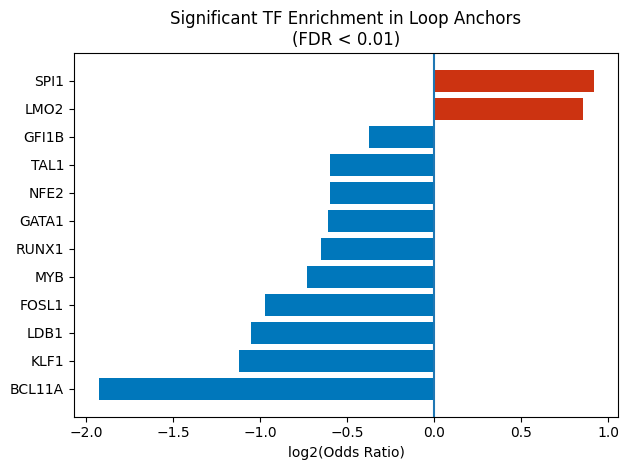

        tf_overlap  control_overlap  tf_not_overlap  control_not_overlap  \
TF                                                                         
BCL11A          40            45558             114                34110   
GATA1        11263            37326           19506                42342   
KLF1          1029            44888            1735                34780   
TAL1          5607            41173            7934                38495   
GFI1B        15492            34182           26715                45486   
NFE2          6236            40289            9235                39379   
LMO2           948            44555             413                35113   
ATF4             2            45588               2                34080   
SPI1          1490            43788             647                35880   
RUNX1         1311            44153            1658                35515   
FOSL1         1298            44566            2002                35102   
MYB         

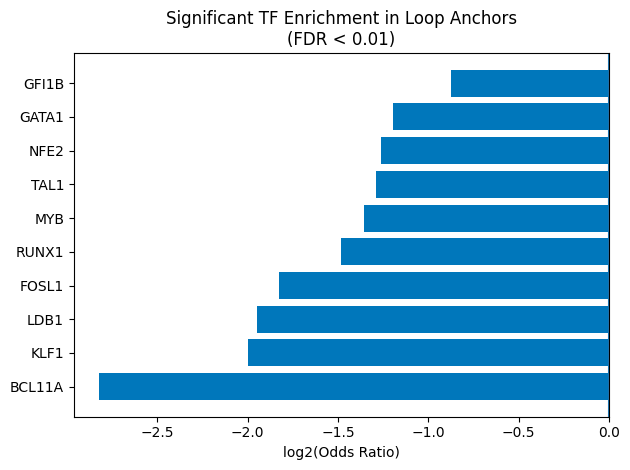

        tf_overlap  control_overlap  tf_not_overlap  control_not_overlap  \
TF                                                                         
BCL11A          40            28398             114                11447   
GATA1        11263            22684           19506                17161   
KLF1          1029            28010            1735                11835   
TAL1          5607            25235            7934                14610   
GFI1B        15492            20522           26715                19323   
NFE2          6236            24645            9235                15200   
LMO2           948            27572             413                12273   
ATF4             2            28415               2                11430   
SPI1          1490            26877             647                12968   
RUNX1         1311            27438            1658                12407   
FOSL1         1298            27774            2002                12071   
MYB         

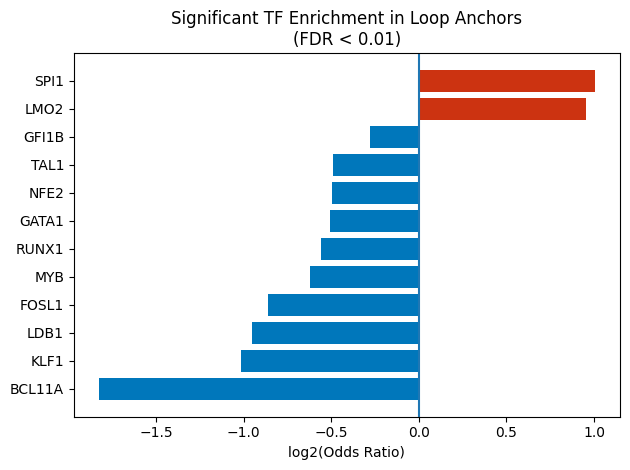

        tf_overlap  control_overlap  tf_not_overlap  control_not_overlap  \
TF                                                                         
BCL11A          40            47839             114                38421   
GATA1        11263            38909           19506                47351   
KLF1          1029            46996            1735                39264   
TAL1          5607            42972            7934                43288   
GFI1B        15492            35663           26715                50597   
NFE2          6236            42098            9235                44162   
LMO2           948            46784             413                39476   
ATF4             2            47870               2                38390   
SPI1          1490            46076             647                40184   
RUNX1         1311            46400            1658                39860   
FOSL1         1298            46676            2002                39584   
MYB         

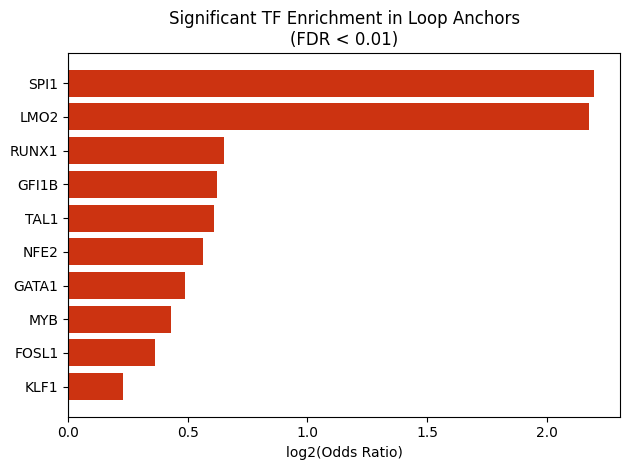

        tf_overlap  control_overlap  tf_not_overlap  control_not_overlap  \
TF                                                                         
BCL11A          40            78333             114               151648   
GATA1        11263            67110           19506               162871   
KLF1          1029            77344            1735               152637   
TAL1          5607            72766            7934               157215   
GFI1B        15492            62881           26715               167100   
NFE2          6236            72135            9235               157846   
LMO2           948            77425             413               152556   
ATF4             2            78371               2               151610   
SPI1          1490            76883             647               153098   
RUNX1         1311            77062            1658               152919   
FOSL1         1298            77075            2002               152906   
MYB         

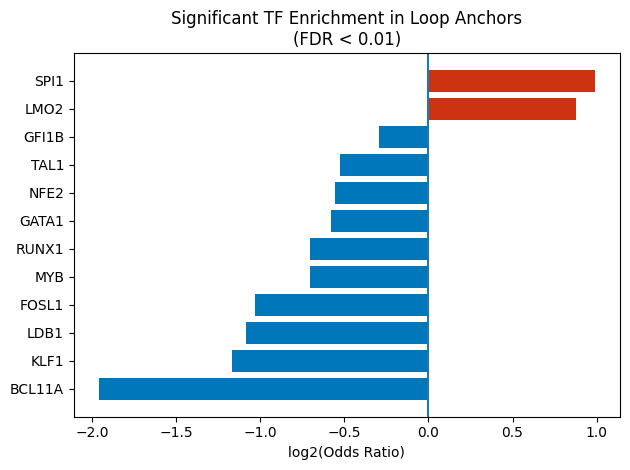

        tf_overlap  control_overlap  tf_not_overlap  control_not_overlap  \
TF                                                                         
BCL11A          40            17063             114                12485   
GATA1        11263            13674           19506                15874   
KLF1          1029            16893            1735                12655   
TAL1          5607            14917            7934                14631   
GFI1B        15492            12266           26715                17282   
NFE2          6236            14706            9235                14842   
LMO2           948            16411             413                13137   
ATF4             2            17069               2                12479   
SPI1          1490            15856             647                13692   
RUNX1         1311            16644            1658                12904   
FOSL1         1298            16834            2002                12714   
MYB         

In [7]:
controls = ["P1_ATAC", "P2_ATAC","P3_ATAC","P123_ATAC",
           "032524_combined_DAP_JAN_028_ATAC", "erythroid_associated_ACRs"]
#controls= ["032524_combined_DAP_JAN_028_ATAC"]
tests = ["erythroid_acrs_by_tf_against_atac", "acrs_by_tf_against_atac"]
for test, control in list(itertools.product(tests, controls)):
    fname = os.path.join(basedir, f"{test}_overlap_results_{control}.txt")
    print(fname)
    df = pd.read_csv(fname, sep="\t", header=None,
                 names=["TF", "tf_overlap", "control_overlap",
                        "tf_not_overlap", "control_not_overlap"])

    df = df.set_index("TF")

    #sd=os.path.join(savedir, f"{test}_overlap_results_{control}.svg")
    out = plot_tf_enrichment(df)
    print(out)

/mnt/md0/varshini/Analysis/Blood/MicroC_Loops_Anchors_Merged_v2/acr_bedfiles_overlap_results_P1_ATAC.txt


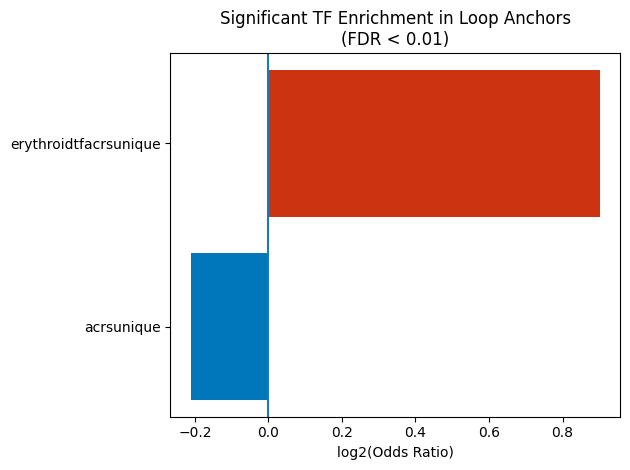

/mnt/md0/varshini/Analysis/Blood/MicroC_Loops_Anchors_Merged_v2/acr_bedfiles_overlap_results_P2_ATAC.txt


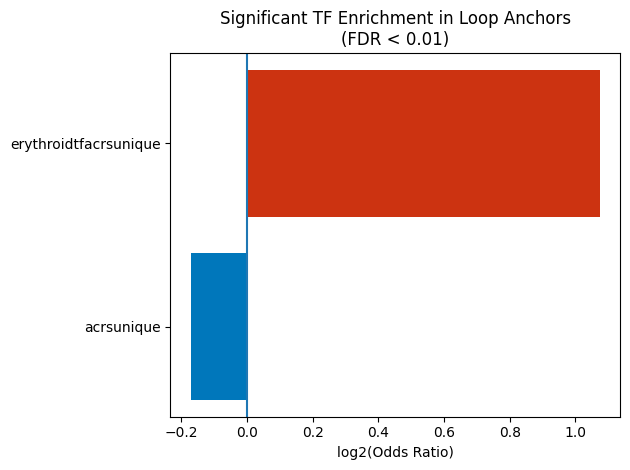

/mnt/md0/varshini/Analysis/Blood/MicroC_Loops_Anchors_Merged_v2/acr_bedfiles_overlap_results_P3_ATAC.txt


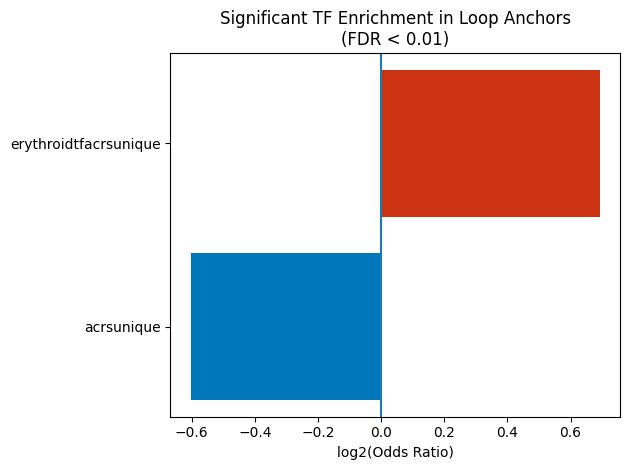

/mnt/md0/varshini/Analysis/Blood/MicroC_Loops_Anchors_Merged_v2/acr_bedfiles_overlap_results_P123_ATAC.txt


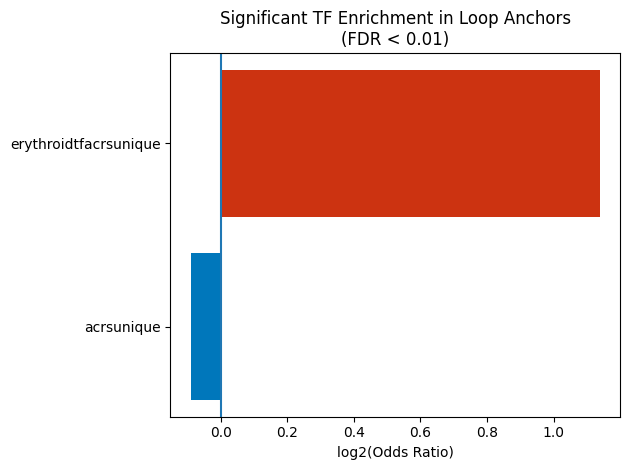

/mnt/md0/varshini/Analysis/Blood/MicroC_Loops_Anchors_Merged_v2/acr_bedfiles_overlap_results_032524_combined_DAP_JAN_028_ATAC.txt


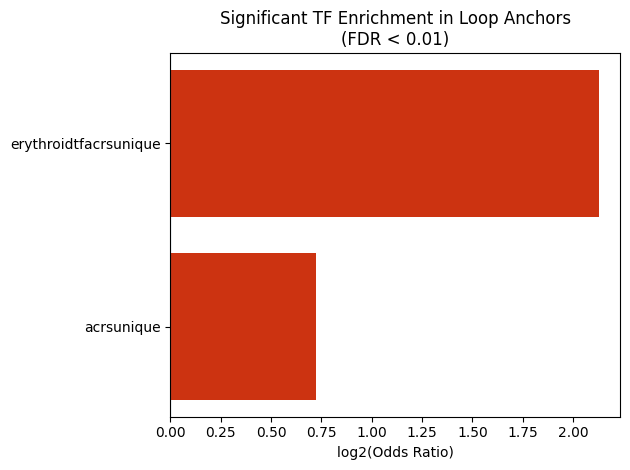

/mnt/md0/varshini/Analysis/Blood/MicroC_Loops_Anchors_Merged_v2/acr_bedfiles_overlap_results_erythroid_associated_ACRs.txt


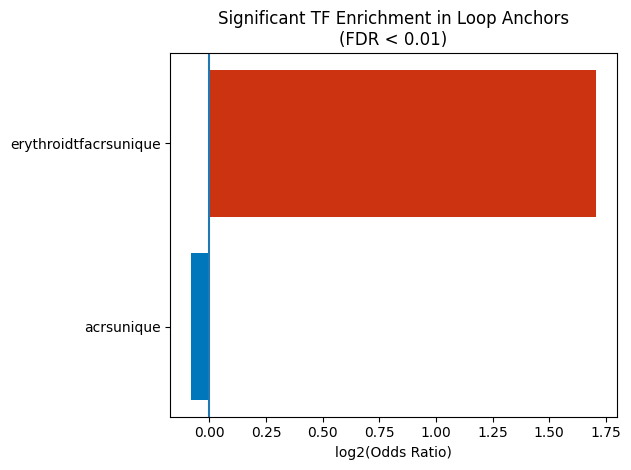

In [22]:
tests = ["acr_bedfiles"]
for test, control in list(itertools.product(tests, controls)):
    fname = os.path.join(basedir, f"{test}_overlap_results_{control}.txt")
    print(fname)
    df = pd.read_csv(fname, sep="\t", header=None,
                 names=["TF", "tf_overlap", "control_overlap",
                        "tf_not_overlap", "control_not_overlap"])

    df = df.set_index("TF")

    plot_tf_enrichment(df)